# Death, Continuity, and Bodily Imagery in Shakespeare’s Hamlet

This project applies Natural Language Processing techniques to selected passages from Shakespeare’s *Hamlet* using Python and spaCy.

The goal is to analyze semantic fields related to death, continuity, the body, decay, memory, and spirituality.

This project combines computational linguistics, literary analysis, and digital humanities.

## Importing Libraries

In [1]:
import spacy
from collections import Counter

nlp = spacy.load("en_core_web_sm")

## Loading Selected Hamlet Passages

In [2]:
text = """
To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles,
And by opposing end them. To die, to sleep—
No more—and by a sleep to say we end
The heart-ache and the thousand natural shocks
That flesh is heir to.

To die, to sleep—
To sleep, perchance to dream. Ay, there's the rub,
For in that sleep of death what dreams may come
When we have shuffled off this mortal coil,
Must give us pause.

Alas, poor Yorick! I knew him, Horatio:
a fellow of infinite jest, of most excellent fancy.
Where be your gibes now? your gambols? your songs?
your flashes of merriment, that were wont to set the table on a roar?

Alexander died, Alexander was buried,
Alexander returneth into dust; the dust is earth;
of earth we make loam.
"""

doc = nlp(text)

## Tokenization, Lemmatization, and POS Tagging

In [3]:
for token in doc:
    print(token.text, token.lemma_, token.pos_)


 
 SPACE
To to PART
be be AUX
, , PUNCT
or or CCONJ
not not PART
to to PART
be be AUX
, , PUNCT
that that PRON
is be AUX
the the DET
question question NOUN
: : PUNCT

 
 SPACE
Whether whether SCONJ
' ' PUNCT
tis tis NUM
nobler nobler NOUN
in in ADP
the the DET
mind mind NOUN
to to PART
suffer suffer VERB

 
 SPACE
The the DET
slings sling NOUN
and and CCONJ
arrows arrow NOUN
of of ADP
outrageous outrageous ADJ
fortune fortune NOUN
, , PUNCT

 
 SPACE
Or or CCONJ
to to PART
take take VERB
arms arm NOUN
against against ADP
a a DET
sea sea NOUN
of of ADP
troubles trouble NOUN
, , PUNCT

 
 SPACE
And and CCONJ
by by ADP
opposing oppose VERB
end end NOUN
them they PRON
. . PUNCT
To to PART
die die VERB
, , PUNCT
to to PART
sleep sleep VERB
— — PUNCT

 
 SPACE
No no ADV
more more ADJ
— — PUNCT
and and CCONJ
by by ADP
a a DET
sleep sleep NOUN
to to PART
say say VERB
we we PRON
end end VERB

 
 SPACE
The the DET
heart heart NOUN
- - PUNCT
ache ache NOUN
and and CCONJ
the the DET
thousand thou

## Semantic Fields

In [4]:
semantic_fields = {
    "death": ["death", "die", "dead", "buried", "grave", "dust"],
    "body": ["flesh", "heart", "arms", "body", "skull", "bones"],
    "continuity": ["sleep", "dream", "return", "earth", "life"],
    "memory": ["knew", "remember", "jest", "fancy", "song"],
    "suffering": ["suffer", "trouble", "shock", "ache", "fortune"]
}

## Counting Semantic Fields

In [5]:
results = {}

for field, words in semantic_fields.items():
    count = 0
    found_words = []

    for token in doc:
        lemma = token.lemma_.lower()

        if lemma in words:
            count += 1
            found_words.append(token.text)

    results[field] = {
        "count": count,
        "words": found_words
    }

for field, data in results.items():
    print(field.upper())
    print("Count:", data["count"])
    print("Words:", data["words"])
    print()

DEATH
Count: 6
Words: ['die', 'die', 'death', 'died', 'dust', 'dust']

BODY
Count: 2
Words: ['heart', 'flesh']

CONTINUITY
Count: 9
Words: ['sleep', 'sleep', 'sleep', 'sleep', 'dream', 'sleep', 'dreams', 'earth', 'earth']

MEMORY
Count: 3
Words: ['jest', 'fancy', 'songs']

SUFFERING
Count: 5
Words: ['suffer', 'fortune', 'troubles', 'ache', 'shocks']



## Frequency Analysis

In [6]:
words = []

for token in doc:
    if token.is_alpha:
        words.append(token.lemma_.lower())

word_frequency = Counter(words)

word_frequency.most_common(20)

[('to', 13),
 ('be', 8),
 ('the', 8),
 ('of', 7),
 ('sleep', 5),
 ('that', 4),
 ('and', 4),
 ('a', 4),
 ('we', 4),
 ('your', 4),
 ('die', 3),
 ('alexander', 3),
 ('or', 2),
 ('not', 2),
 ('in', 2),
 ('by', 2),
 ('end', 2),
 ('dream', 2),
 ('dust', 2),
 ('earth', 2)]

## Literary Interpretation

The computational analysis shows that the selected passages from *Hamlet* strongly connect death with sleep, dreams, the body, memory, and material continuity.

The semantic field of death includes words such as “die,” “death,” “buried,” and “dust.” However, death is not presented only as an ending. It is also associated with sleep, dreams, earth, and return. This suggests that Shakespeare represents death as both a physical ending and a mysterious continuation.

The bodily imagery is also significant. Words such as “flesh,” “heart,” and “arms” connect existential suffering with the material body. In the Yorick passage, memory and decay come together: Yorick is remembered as a living person, but his body has become an emblem of mortality.

Overall, this project shows how NLP can support literary interpretation by identifying repeated semantic patterns across selected passages.

## Creating a DataFrame with Semantic Field Frequencies

In this section, the semantic field results are converted into a pandas DataFrame. This makes the results easier to read, compare, and later visualize.

In [7]:
import pandas as pd

data = []

for field, info in results.items():
    data.append({
        "Semantic Field": field,
        "Frequency": info["count"],
        "Found Words": ", ".join(info["words"])
    })

df = pd.DataFrame(data)

df

,Semantic Field,Frequency,Found Words
0,death,6,"die, die, death, died, dust, dust"
1,body,2,"heart, flesh"
2,continuity,9,"sleep, sleep, sleep, sleep, dream, sleep, drea..."
3,memory,3,"jest, fancy, songs"
4,suffering,5,"suffer, fortune, troubles, ache, shocks"


## Visualizing Semantic Field Frequencies

The following visualization compares the frequency of semantic fields in Hamlet. This helps identify dominant conceptual patterns related to death, continuity, suffering, memory, and the body.

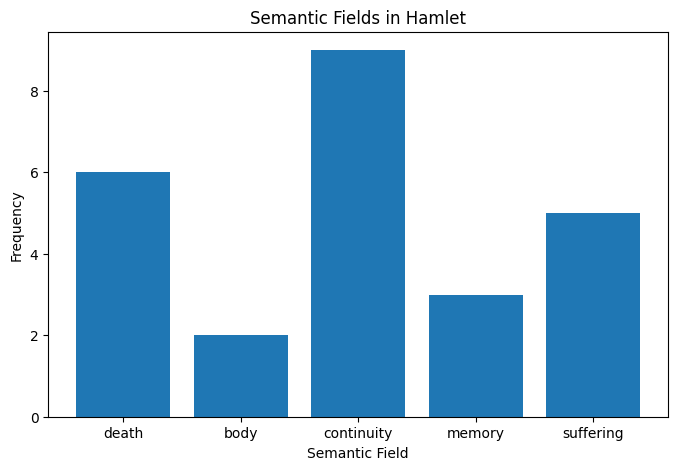

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(df["Semantic Field"], df["Frequency"])

plt.xlabel("Semantic Field")
plt.ylabel("Frequency")
plt.title("Semantic Fields in Hamlet")

plt.show()

## Interpreting the Visualization

The bar chart shows that the semantic field of continuity has the highest frequency in the selected Hamlet passages, followed by death and suffering.

This suggests that death in Hamlet is not represented only as an ending. It is repeatedly connected to sleep, dreams, return, dust, and earth. In this sense, death becomes linked to continuity and transformation.

The lower frequency of body-related terms does not mean that the body is unimportant. Instead, the body appears in highly meaningful images such as flesh and heart, connecting mortality with physical suffering.

Overall, the visualization supports the idea that Shakespeare represents death as both bodily decay and a mysterious form of continuation.

## Scene Comparison

This section compares semantic fields across different Hamlet passages in order to identify how Shakespeare shifts thematic emphasis between scenes.

In [9]:
scene1 = """
To be, or not to be: that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them. To die, to sleep—
No more.
"""

In [10]:
scene2 = """
Alas, poor Yorick! I knew him, Horatio.
A fellow of infinite jest, of most excellent fancy.
Here hung those lips that I have kissed I know not how oft.
Where be your gibes now? your songs? your flashes of merriment?
"""

In [11]:
doc1 = nlp(scene1)
doc2 = nlp(scene2)

In [12]:
def count_semantic_fields(doc, semantic_fields):

    results = {}

    for field, words in semantic_fields.items():

        count = 0

        for token in doc:

            if token.lemma_.lower() in words:
                count += 1

        results[field] = count

    return results

In [13]:
semantic_fields = {

    "death": ["die", "death", "grave", "dust"],

    "continuity": ["sleep", "dream"],

    "suffering": ["suffer", "trouble"],

    "memory": ["remember", "know", "memory"],

    "body": ["lip", "flesh", "heart"]
}

In [14]:
scene1_results = count_semantic_fields(doc1, semantic_fields)

scene2_results = count_semantic_fields(doc2, semantic_fields)

print(scene1_results)

print(scene2_results)

{'death': 1, 'continuity': 1, 'suffering': 2, 'memory': 0, 'body': 0}
{'death': 0, 'continuity': 0, 'suffering': 0, 'memory': 2, 'body': 1}


## Comparing Semantic Fields Across Scenes

The results reveal clear thematic differences between the two Hamlet passages.

The “To be or not to be” soliloquy emphasizes suffering, death, and continuity through philosophical reflection. In contrast, the Yorick scene focuses more strongly on memory and bodily imagery.

This suggests that Shakespeare approaches mortality differently across scenes: abstractly and philosophically in the soliloquy, but materially and personally in the graveyard scene.

In [15]:
comparison_df = pd.DataFrame({

    "Scene 1": scene1_results,

    "Scene 2": scene2_results

})

comparison_df

,Scene 1,Scene 2
death,1,0
continuity,1,0
suffering,2,0
memory,0,2
body,0,1


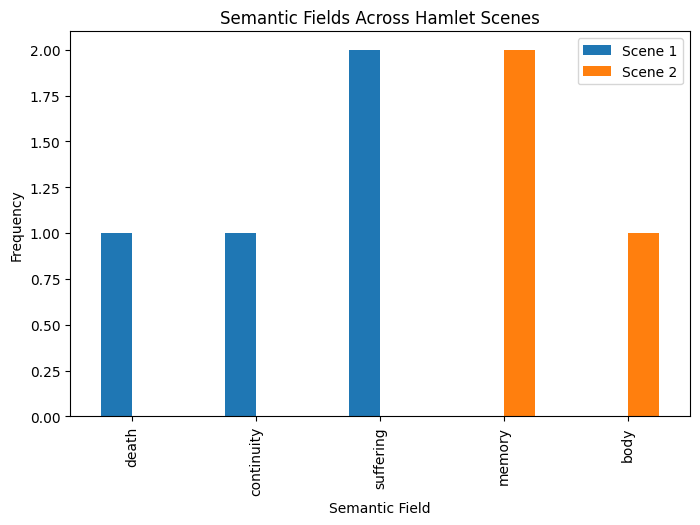

In [16]:
comparison_df.plot(kind="bar", figsize=(8,5))

plt.title("Semantic Fields Across Hamlet Scenes")

plt.xlabel("Semantic Field")

plt.ylabel("Frequency")

plt.show()

## Scene Comparison Interpretation

The comparison shows that the “To be or not to be” passage contains more vocabulary related to suffering, death, and continuity. This reflects the abstract and philosophical nature of the soliloquy, where Hamlet thinks about existence, pain, sleep, dreams, and death.

The Yorick scene, by contrast, contains more vocabulary related to memory and the body. This suggests a more material and personal approach to mortality: Hamlet does not only think about death as an idea, but confronts it through the remembered body of Yorick.

This comparison shows that Shakespeare represents death in different ways across scenes: philosophically in the soliloquy and materially through memory and bodily imagery in the graveyard scene.

## Regex Pattern Matching

This section uses regular expressions to search for repeated expressions and death-related patterns in the selected Hamlet passages.

In [17]:
import re

patterns = {
    "to be": r"\bto be\b",
    "to die": r"\bto die\b",
    "to sleep": r"\bto sleep\b",
    "death words": r"\bdeath|die|died|dead|buried|dust\b"
}

for label, pattern in patterns.items():
    matches = re.findall(pattern, text.lower())
    print(label, ":", matches)
    print("count:", len(matches))
    print()

to be : ['to be', 'to be']
count: 2

to die : ['to die', 'to die']
count: 2

to sleep : ['to sleep', 'to sleep', 'to sleep']
count: 3

death words : ['die', 'die', 'death', 'die', 'buried', 'dust', 'dust']
count: 7



## Interpreting the Regex Results

The regex analysis highlights repeated expressions associated with death, sleep, and existence.

Expressions such as “to die” and “to sleep” are especially important because Shakespeare repeatedly connects death with sleep and dreaming. This supports the idea that death in Hamlet is represented not only as annihilation, but also as uncertainty, transition, and continuity.

The repeated phrase “to be” also reinforces the existential dimension of the soliloquy. Hamlet’s language continually returns to questions of existence, suffering, and the unknown nature of death.